# EDA — Text Classification

## Import libraries

In [1]:
import string
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

## Load Data

In [2]:
train_data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

test_data = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

In [3]:
train_df = pd.DataFrame({
    'text': train_data.data,
    'target': train_data.target,
    'target_name': [train_data.target_names[i] for i in train_data.target]
})

print(f"Train shape: {len(train_df)}")
print(f"Number of classes: {len(train_data.target_names)}")

Train shape: 11314
Number of classes: 20


## Data Types & Info

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11314 entries, 0 to 11313
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         11314 non-null  str  
 1   target       11314 non-null  int64
 2   target_name  11314 non-null  str  
dtypes: int64(1), str(2)
memory usage: 265.3 KB


There is no null entry

In [5]:
train_df.describe()

,target
count,11314.000000
mean,9.293000
std,5.562719
min,0.000000
25%,5.000000
50%,9.000000
75%,14.000000
max,19.000000


In [6]:
train_df.head()

,text,target,target_name
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


## Check Missing Values & Duplicates

In [7]:
# Missing value
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)

missing_report = pd.DataFrame({"Missing": missing, "Percent (%)": missing_pct})
print(
    missing_report[missing_report["Missing"] > 0]
    if missing.sum() > 0
    else "No missing value"
)

No missing value


In [8]:
# Duplicates
dup_count = train_df.duplicated().sum()
print("Duplicates: ", dup_count)

Duplicates:  254


In [9]:
duplicate_rows = train_df[train_df.duplicated(keep=False)]

duplicate_rows_sorted = duplicate_rows.sort_values(by='text')

print("Duplicate examples:")
display(duplicate_rows_sorted.head(4))

Duplicate examples:


,text,target,target_name
5260,,3,comp.sys.ibm.pc.hardware
6296,,9,rec.sport.baseball
6324,,2,comp.os.ms-windows.misc
6385,,11,sci.crypt


The duplicate entries consist mainly of empty strings, they should be removed before training.

## Target Distribution

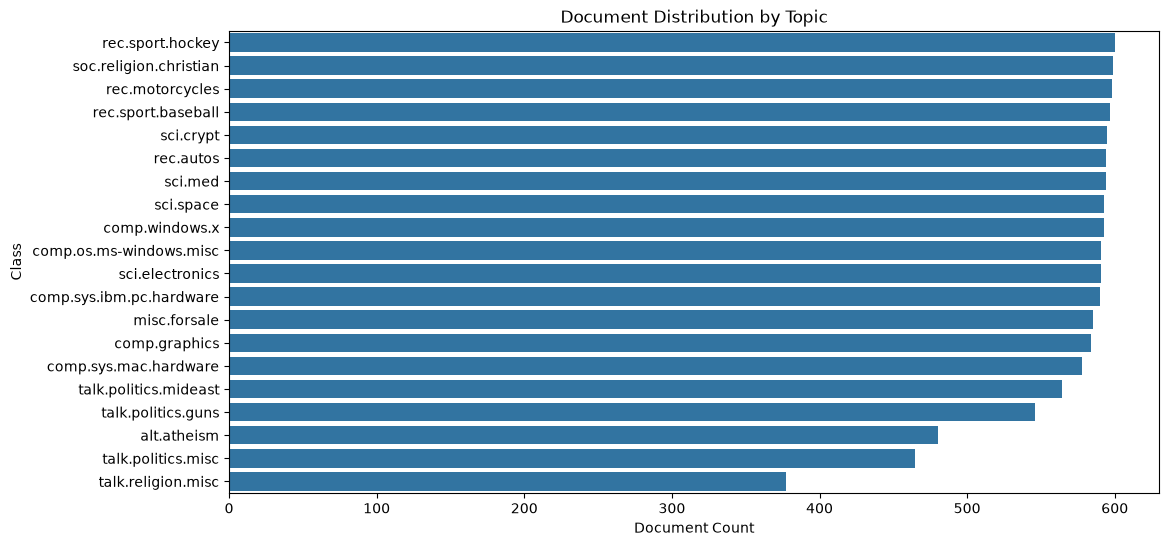

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, y='target_name', order=train_df['target_name'].value_counts().index)
plt.title('Document Distribution by Topic')
plt.xlabel('Document Count')
plt.ylabel('Class')
plt.show()

The class distribution is relatively balanced across all 20 categories. This is an ideal scenario for text classification, meaning we will not need to apply complex resampling techniques

We can select 4 distinct topics: **sci.space**, **rec.sport.hockey**, **comp.graphics**, and **talk.politics.misc**. By focusing on these categories, we can easily visualize how our model distinguishes between completely different subjects. If the model can clearly separate these 4, it is highly likely to perform well on the full 20-category set.

In [11]:
DEFAULT_CATEGORIES = [
    "sci.space",
    "rec.sport.hockey",
    "comp.graphics",
    "talk.politics.misc",
]

train_df = train_df[train_df['target_name'].isin(DEFAULT_CATEGORIES)]
train_df = train_df.reset_index(drop=True)

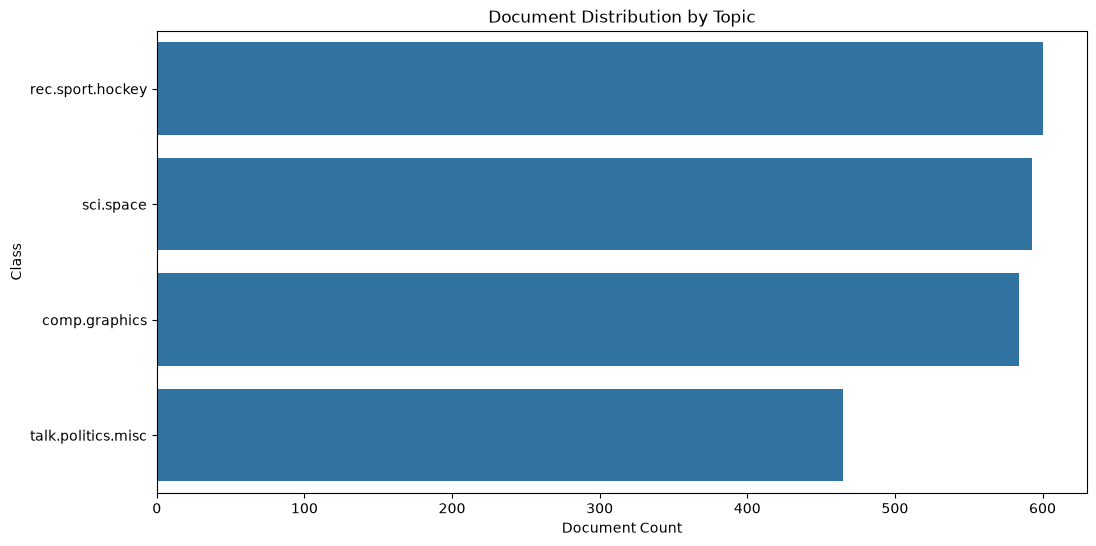

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, y='target_name', order=train_df['target_name'].value_counts().index)
plt.title('Document Distribution by Topic')
plt.xlabel('Document Count')
plt.ylabel('Class')
plt.show()

##Text Length Analysis

In [13]:
# Count number of words
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))
empty_docs = len(train_df[train_df['word_count'] == 0])
print(f"Number of empty texts: {empty_docs}")

Number of empty texts: 56


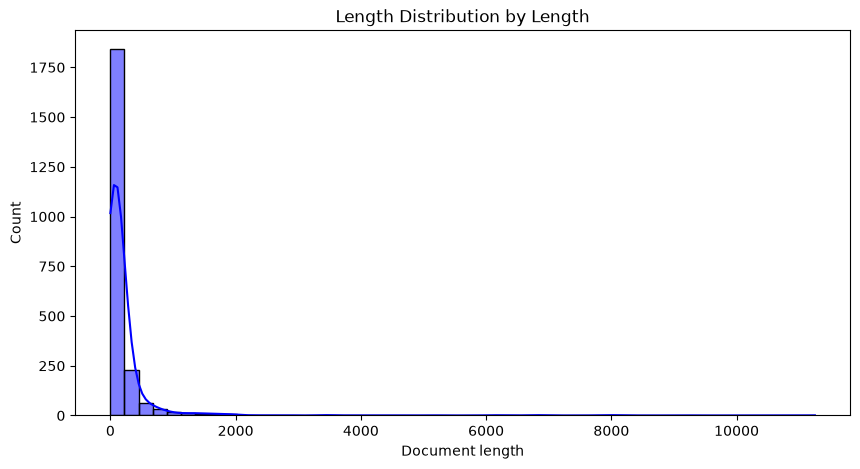

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=50, kde=True, color='blue')
plt.title('Length Distribution by Length')
plt.xlabel('Document length')
plt.ylabel('Count')
plt.show()

Stripping headers, footers, and quotes exposed a critical data quality issue: there are documents are now completely empty. We must drop rows with a word count of 0 before proceeding to the modeling phase.

The distribution is heavily right-skewed, with most documents containing fewer than 200 words. The long tail indicates a small number of very long articles.

## Top Frequent Lexical Analysis

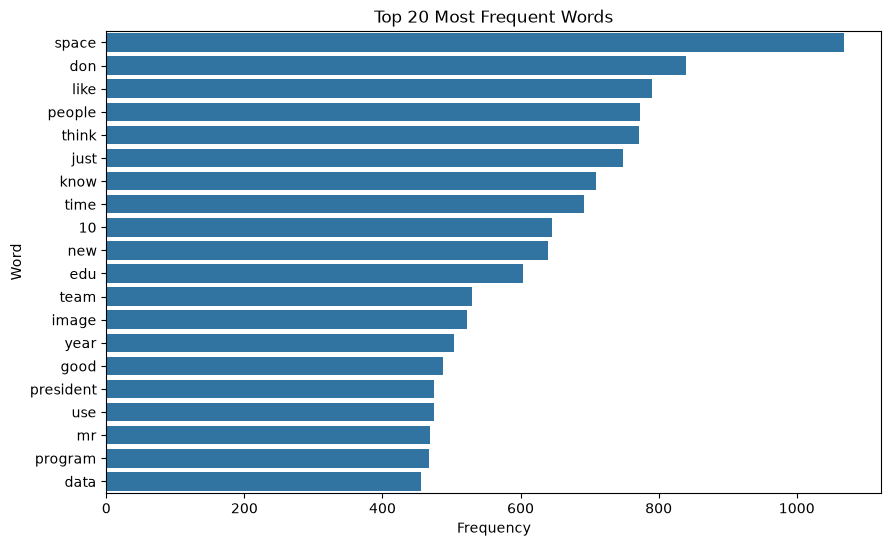

In [15]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X_counts = vectorizer.fit_transform(train_df['text'])

words = vectorizer.get_feature_names_out()
frequencies = X_counts.sum(axis=0).A1

df_freq = pd.DataFrame({'word': words, 'freq': frequencies}).sort_values(by='freq', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_freq, x='freq', y='word')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

Although stop words were supposedly removed, the high frequency of residual tokens like "don", "like", and "just" indicates that the text preprocessing step needs further refinement to reduce noise.

## Punctation & Number Analysis

In [16]:
train_df['char_count'] = train_df['text'].apply(len)
train_df['punct_count'] = train_df['text'].apply(lambda x: len([c for c in x if c in string.punctuation]))

train_df['digit_count'] = train_df['text'].apply(lambda x: len(re.findall(r'\d', x)))

train_df['punct_ratio'] = train_df['punct_count'] / (train_df['char_count'] + 1)
train_df['digit_ratio'] = train_df['digit_count'] / (train_df['char_count'] + 1)

print("Top 5 texts with the highest PUNCTUATION RATIO:")
display(train_df.sort_values(by='punct_ratio', ascending=False)[['target_name', 'punct_ratio', 'text']].head(5))

print("Top 5 texts with the highest DIGIT RATIO:")
display(train_df.sort_values(by='digit_ratio', ascending=False)[['target_name', 'digit_ratio', 'text']].head(5))

Top 5 texts with the highest PUNCTUATION RATIO:


,target_name,punct_ratio,text
1543,comp.graphics,0.975000,==============================================...
1618,comp.graphics,0.972973,------------------------------------
723,talk.politics.misc,0.897727,\n ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^...
114,rec.sport.hockey,0.750000,;^)
1020,talk.politics.misc,0.645669,==============================================...


Top 5 texts with the highest DIGIT RATIO:


,target_name,digit_ratio,text
1934,rec.sport.hockey,0.406491,*** NATIONAL HOCKEY LEAGUE ***\n ...
1342,sci.space,0.300139,"I have the ""osculating elements at perigee"" of..."
430,rec.sport.hockey,0.287810,FINAL 1992-93 AMERICAN HOCKEY LEAGUE STANDINGS...
2110,rec.sport.hockey,0.274942,"Well, I'm back from Tokyo, so here are the sta..."
1702,rec.sport.hockey,0.270759,Here are the standings after the April 6 updat...


In [17]:
train_df.loc[1543]["text"]

'==============================================================================\n'

In [18]:
train_df.loc[1934]["text"]

'*** NATIONAL HOCKEY LEAGUE ***\n                                 92-93 SEASON\n\n                            HOME ATTENDANCE REPORT\n\n Each Qtr. represents 10 home games,   Qtr. 4 will have 11 home games.\n Neutral site games are not included.  S/O indicates the number of sell-outs.\n\nTeam\nName   Qtr. 1   S/O  Qtr. 2   S/O  Qtr. 3   S/O  Qtr. 4   S/O   Totals   Average\n================================================================================\nBOS    140,573   5   142,694   7   142,768   6   152,468   8    578,503   14,109\nBUF    144,701   0   148,516   3   152,133   5   168,878   4    614,228   14,981\nCAL    190,125   1   196,174   3   196,982   4   217,346   5    800,627   19,527\nCHI    176,372  10   176,746   9   177,981  10   196,749  11    727,848   17,752\nDET    196,330  10   196,670  10   197,228  10   217,167  10    807,395   19,692\nEDM    139,038   0   149,422   2   152,831   2   165,384   2    606,675   14,796\nHAR     92,994   0   110,670   2   108,651   0   

Texts exhibiting unusually high ratios of punctuation marks or digits generally represent tabular data, code blocks, or residual PGP signatures rather than natural human language. Identifying and setting a threshold to filter out these statistical outliers will significantly enhance the linguistic purity of our training corpus.

## Class-specific Lexical Analysis

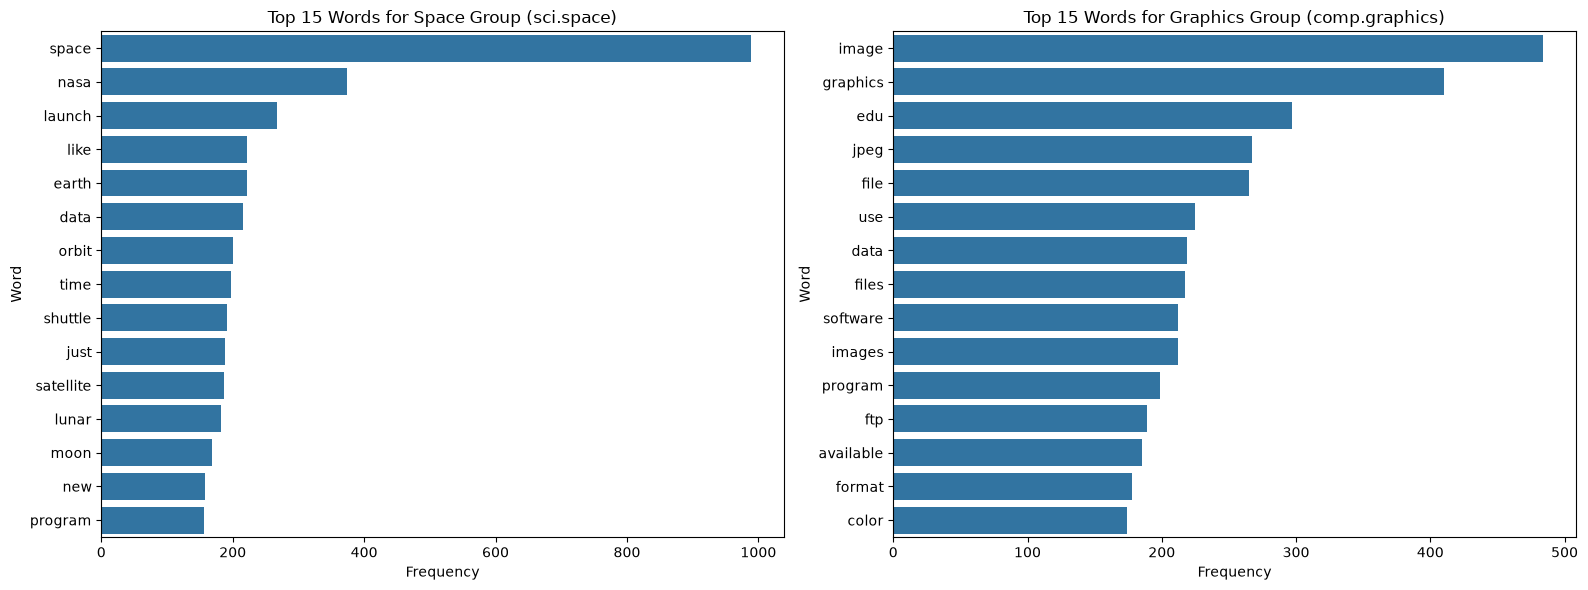

In [19]:
def get_top_words_for_class(df, class_name, top_n=15):
    corpus = df[df['target_name'] == class_name]['text']

    vec = CountVectorizer(stop_words='english', max_features=1000)
    X = vec.fit_transform(corpus)

    words = vec.get_feature_names_out()
    freqs = X.sum(axis=0).A1

    df_freq = pd.DataFrame({'word': words, 'freq': freqs}).sort_values(by='freq', ascending=False)
    return df_freq.head(top_n)

df_space = get_top_words_for_class(train_df, 'sci.space')
df_graphics = get_top_words_for_class(train_df, 'comp.graphics')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], data=df_space, x='freq', y='word')
axes[0].set_title('Top 15 Words for Space Group (sci.space)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

sns.barplot(ax=axes[1], data=df_graphics, x='freq', y='word')
axes[1].set_title('Top 15 Words for Graphics Group (comp.graphics)')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

plt.tight_layout()
plt.show()

Comparing the lexical features of distinct classes (e.g., **sci.space** vs. **comp.graphics**) demonstrates excellent semantic separation. Each class is tightly clustered around its specific domain vocabulary. This strong distinctiveness suggests that once the noise is properly cleaned, even traditional algorithms like Naive Bayes or Logistic Regression (paired with TF-IDF) will achieve high accuracy.

## Summary

| EDA Phase | Key Finding | Action Required / Next Steps |
| :--- | :--- | :--- |
| **Class Distribution** | Target labels are well-balanced. | Proceed without class weighting. Use 4 classes: **sci.space**, **rec.sport.hockey**, **comp.graphics**, and **talk.politics.misc** |
| **Text Length** | High volume of empty documents post-stripping. | Filter out rows where `word_count == 0` to remove blank contexts. |
| **Lexical Noise** | High presence of incomplete tokens ('don', 've') and common filler words ('like', 'just'). | Expand the custom stop-word list. |
| **Special Characters** | Outliers with excessive punctuation/digits represent code or tables. | Drop or heavily normalize documents exceeding a strict threshold. |
| **Semantic Separation** | Clear vocabulary boundaries exist between disparate topics. | High confidence in model convergence post-cleaning. Proceed to TF-IDF vectorization. |